# Feature Engineering

---

STEPS:
1. Import necessary packages
2. Use Pandas to load data
3. Feature engineering

---

## 1. Import necessary packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Use Pandas to load data

In [3]:
df = pd.read_csv('./Task4_CleanedDataAfterEDA.csv')

# Reformat date categories
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [4]:
df.head(5)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0.000011,2.896760e-06,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0


---

## 3. Feature engineering

### Difference between off-peak prices in December and preceding January

Below is the code created by another colleague to calculate the feature described above.

In [5]:
price_df = pd.read_csv('Task3_PriceData.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [6]:

# Group off-peak prices by each company/customer and each month (i.e., Company1/month1,...,Company1/month12, Company2/month1,...,Company2/month12, etc.)
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()
#print(monthly_price_by_id)

# Get January and December prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()
#print(jan_prices)
#print(dec_prices)

# Calculate the difference between January and December prices (renaming columns at first so as not to confuse the columns)
diff_jan_dec = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff_jan_dec['offpeak_diff_dec_january_energy'] = diff_jan_dec['dec_1'] - diff_jan_dec['price_off_peak_var']
diff_jan_dec['offpeak_diff_dec_january_power'] = diff_jan_dec['dec_2'] - diff_jan_dec['price_off_peak_fix']
diff_jan_dec = diff_jan_dec[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff_jan_dec.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


In [7]:
# Put this newly engineered feature into the dataframe we're working on
df = pd.merge(df, diff_jan_dec, on='id')
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1,0.020057,3.700961
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0,-0.003767,0.177779
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0,-0.004670,0.177779
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0,-0.004547,0.177779
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0,-0.006192,0.162916


---

## Average price changes across periods

Now, let's enhance the engineered feature our colleague suggested by calculating the average price changes across individual periods, instead of the entire year.

In [8]:
# Aggregate average prices per period by company
mean_prices_per_company = price_df.groupby(['id']).agg({
    'price_off_peak_var': 'mean', 
    'price_peak_var': 'mean', 
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'    
}).reset_index()
print(mean_prices_per_company)

                                     id  price_off_peak_var  price_peak_var  \
0      0002203ffbb812588b632b9e628cc38d            0.124338        0.103794   
1      0004351ebdd665e6ee664792efc4fd13            0.146426        0.000000   
2      0010bcc39e42b3c2131ed2ce55246e3c            0.181558        0.000000   
3      0010ee3855fdea87602a5b7aba8e42de            0.118757        0.098292   
4      00114d74e963e47177db89bc70108537            0.147926        0.000000   
...                                 ...                 ...             ...   
16091  ffef185810e44254c3a4c6395e6b4d8a            0.138863        0.115125   
16092  fffac626da707b1b5ab11e8431a4d0a2            0.147137        0.000000   
16093  fffc0cacd305dd51f316424bbb08d1bd            0.153879        0.129497   
16094  fffe4f5646aa39c7f97f95ae2679ce64            0.123858        0.103499   
16095  ffff7fa066f1fb305ae285bb03bf325a            0.125360        0.104895   

       price_mid_peak_var  price_off_peak_fix  pric

In [9]:
# Calculate the difference of means between consecutive periods
mean_prices_per_company['off_peak_peak_var_mean_diff'] = mean_prices_per_company['price_off_peak_var'] - mean_prices_per_company['price_peak_var']
mean_prices_per_company['peak_mid_peak_var_mean_diff'] = mean_prices_per_company['price_peak_var'] - mean_prices_per_company['price_mid_peak_var']
mean_prices_per_company['off_peak_mid_peak_var_mean_diff'] = mean_prices_per_company['price_off_peak_var'] - mean_prices_per_company['price_mid_peak_var']
mean_prices_per_company['off_peak_peak_fix_mean_diff'] = mean_prices_per_company['price_off_peak_fix'] - mean_prices_per_company['price_peak_fix']
mean_prices_per_company['peak_mid_peak_fix_mean_diff'] = mean_prices_per_company['price_peak_fix'] - mean_prices_per_company['price_mid_peak_fix']
mean_prices_per_company['off_peak_mid_peak_fix_mean_diff'] = mean_prices_per_company['price_off_peak_fix'] - mean_prices_per_company['price_mid_peak_fix']

In [10]:
# Create these new columns for our dataframe and put the newly engineered features into it
columns = [
    'id', 
    'off_peak_peak_var_mean_diff',
    'peak_mid_peak_var_mean_diff', 
    'off_peak_mid_peak_var_mean_diff',
    'off_peak_peak_fix_mean_diff', 
    'peak_mid_peak_fix_mean_diff', 
    'off_peak_mid_peak_fix_mean_diff'
]

df = pd.merge(df, mean_prices_per_company[columns], on='id')
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_mid_peak,churn,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,4.423670e+01,1,0.020057,3.700961,0.024038,0.034219,0.058257,18.590255,7.450670,26.040925
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000000e+00,0,-0.003767,0.177779,0.142485,0.007124,0.149609,44.311375,0.000000,44.311375
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000000e+00,0,-0.004670,0.177779,0.082090,0.088421,0.170512,44.385450,0.000000,44.385450
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000000e+00,0,-0.004547,0.177779,0.151210,0.000000,0.151210,44.400265,0.000000,44.400265
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,4.860000e-10,0,-0.006192,0.162916,0.020536,0.030773,0.051309,16.275263,8.137629,24.412893


These features may be useful because they add levels of detail that were not captured in the colleague's previous feature. That is, instead of looking at differences across an entire year (January to December), we have created features that look at mean average price differences across different time periods (`off_peak`, `peak`, `mid_peak`). The previous feature may reveal macro patterns that occur over an entire year, whereas these features may reveal patterns on a micro scale between months.

---

## Max price changes across periods and months

Another path we can take with our colleague's Jan-Dec feature is to look at the maximum change in prices across different time periods and months.

In [11]:
# Aggregate average prices per period by company
mean_prices_by_month_per_company = price_df.groupby(['id', 'price_date']).agg({
    'price_off_peak_var': 'mean', 
    'price_peak_var': 'mean', 
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'    
}).reset_index()
print(mean_prices_by_month_per_company)

                                      id price_date  price_off_peak_var  \
0       0002203ffbb812588b632b9e628cc38d 2015-01-01            0.126098   
1       0002203ffbb812588b632b9e628cc38d 2015-02-01            0.126098   
2       0002203ffbb812588b632b9e628cc38d 2015-03-01            0.128067   
3       0002203ffbb812588b632b9e628cc38d 2015-04-01            0.128067   
4       0002203ffbb812588b632b9e628cc38d 2015-05-01            0.128067   
...                                  ...        ...                 ...   
192997  ffff7fa066f1fb305ae285bb03bf325a 2015-08-01            0.119916   
192998  ffff7fa066f1fb305ae285bb03bf325a 2015-09-01            0.119916   
192999  ffff7fa066f1fb305ae285bb03bf325a 2015-10-01            0.119916   
193000  ffff7fa066f1fb305ae285bb03bf325a 2015-11-01            0.119916   
193001  ffff7fa066f1fb305ae285bb03bf325a 2015-12-01            0.119916   

        price_peak_var  price_mid_peak_var  price_off_peak_fix  \
0             0.103975           

In [12]:
# Calculate the mean difference between consecutive periods
mean_prices_by_month_per_company['off_peak_peak_var_mean_diff'] = mean_prices_by_month_per_company['price_off_peak_var'] - mean_prices_by_month_per_company['price_peak_var']
mean_prices_by_month_per_company['peak_mid_peak_var_mean_diff'] = mean_prices_by_month_per_company['price_peak_var'] - mean_prices_by_month_per_company['price_mid_peak_var']
mean_prices_by_month_per_company['off_peak_mid_peak_var_mean_diff'] = mean_prices_by_month_per_company['price_off_peak_var'] - mean_prices_by_month_per_company['price_mid_peak_var']
mean_prices_by_month_per_company['off_peak_peak_fix_mean_diff'] = mean_prices_by_month_per_company['price_off_peak_fix'] - mean_prices_by_month_per_company['price_peak_fix']
mean_prices_by_month_per_company['peak_mid_peak_fix_mean_diff'] = mean_prices_by_month_per_company['price_peak_fix'] - mean_prices_by_month_per_company['price_mid_peak_fix']
mean_prices_by_month_per_company['off_peak_mid_peak_fix_mean_diff'] = mean_prices_by_month_per_company['price_off_peak_fix'] - mean_prices_by_month_per_company['price_mid_peak_fix']

In [13]:
# Calculate the maximum monthly difference across time periods
max_diff_across_periods_months = mean_prices_by_month_per_company.groupby(['id']).agg({
    'off_peak_peak_var_mean_diff': 'max',
    'peak_mid_peak_var_mean_diff': 'max',
    'off_peak_mid_peak_var_mean_diff': 'max',
    'off_peak_peak_fix_mean_diff': 'max',
    'peak_mid_peak_fix_mean_diff': 'max',
    'off_peak_mid_peak_fix_mean_diff': 'max'
}).reset_index().rename(
    columns={
        'off_peak_peak_var_mean_diff': 'off_peak_peak_var_max_monthly_diff',
        'peak_mid_peak_var_mean_diff': 'peak_mid_peak_var_max_monthly_diff',
        'off_peak_mid_peak_var_mean_diff': 'off_peak_mid_peak_var_max_monthly_diff',
        'off_peak_peak_fix_mean_diff': 'off_peak_peak_fix_max_monthly_diff',
        'peak_mid_peak_fix_mean_diff': 'peak_mid_peak_fix_max_monthly_diff',
        'off_peak_mid_peak_fix_mean_diff': 'off_peak_mid_peak_fix_max_monthly_diff'
    }
)

In [14]:
# Create these new columns for our dataframe and put the newly engineered features into it
columns = [
    'id',
    'off_peak_peak_var_max_monthly_diff',
    'peak_mid_peak_var_max_monthly_diff',
    'off_peak_mid_peak_var_max_monthly_diff',
    'off_peak_peak_fix_max_monthly_diff',
    'peak_mid_peak_fix_max_monthly_diff',
    'off_peak_mid_peak_fix_max_monthly_diff'
]

df = pd.merge(df, max_diff_across_periods_months[columns], on='id')
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff,off_peak_peak_var_max_monthly_diff,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.058257,18.590255,7.450670,26.040925,0.060550,0.085483,0.146033,44.266930,8.145775,44.26693
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.149609,44.311375,0.000000,44.311375,0.151367,0.085483,0.151367,44.444710,0.000000,44.44471
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.170512,44.385450,0.000000,44.385450,0.084587,0.089162,0.172468,44.444710,0.000000,44.44471
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.151210,44.400265,0.000000,44.400265,0.153133,0.000000,0.153133,44.444710,0.000000,44.44471
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0.051309,16.275263,8.137629,24.412893,0.022225,0.033743,0.055866,16.291555,8.145775,24.43733


Calculating the maximum price change between months and time periods could be a good feature to create because customers might be more likely to churn if they experience sudden large price changes.

---

## Further feature engineering

This section includes some other feature engineering that doesn't further enhance the Jan-Dec feature. It also includes different ways you can transform your data to account for some of the statistical properties we saw before, like skewness.

### Tenure

(i.e., How long a company has been a client of PowerCo.)

In [15]:
df['date_activ'] = pd.to_datetime(df['date_activ'])
df['date_end']   = pd.to_datetime(df['date_end'])

df['tenure'] = ((df['date_end'] - df['date_activ']).dt.days// 365)

In [16]:
# Group by the 'tenure' column and then averages the 'churn' column by each tenure group (effectively calculating the % of customers who churn for each tenure group)
df.groupby(['tenure']).agg({'churn': 'mean'}).sort_values(by='tenure', ascending=False)

,churn
tenure,
13,0.095238
12,0.083333
11,0.059783
10,0.045455
9,0.012500
8,0.047244
7,0.075472
6,0.075407
5,0.091999


We can see that companies that only been a client for 4 months or less are much more likely to churn compared to companies that have been a client for longer. Interestingly, the difference between 4 and 5 months is about 4%, which represents a large jump in likelihood for a customer to churn compared to the other differences between tenure values. Perhaps this means that something happens every 4 months that is a large milestone with respect to keeping them as long-term customers.

This would be an interesting feature to keep up with for modeling because tenure is clearly correlated with churn probability.

### Transforming dates into months

Let's create the following: 
- months_activ --> Number of months active until reference date
- months_to_end --> Number of months of the contract left until reference date
- months_modif_prod --> Number of months since last modification until reference date
- months_renewal --> Number of months since last renewal until reference date

In [17]:
def convert_months(reference_date, df, column):
    """
    Returns a number of whole months between two dates

    Parameters:
        - reference_date: Reference date; largely the target date we're looking at for this calculation
        - df: Dataframe that includes data needed for calculation
        - column: Feature we're looking at for the calculation

    Returns:
        - A number of months between two dates
    """
    dates = pd.to_datetime(df[column])

    # Note - ".dt.day" extracts days, ".dt.month" extracts months, and ".dt.year" extracts years
    
    year_diff  = reference_date.year  - dates.dt.year
    month_diff = reference_date.month - dates.dt.month

    # Initial month count
    months = year_diff * 12 + month_diff

    # Subtract 1 from 'months' if the reference day hasn't been reached yet in that month
    months = months - (reference_date.day < dates.dt.day).astype(int)

    return months

Dates as a datetime object are not useful for a predictive model, so we needed to use the datetimes to create some other features that may hold some predictive power. 

Intuitively speaking, one could assume that a client who has been an active client of PowerCo for a longer amount of time may have more loyalty to the brand and is more likely to stay, whereas a newer client may be more volatile. Hence, the addition of the `months_activ` feature.

In addition, if customers are coming up to a contract end date, there may be a natural break point where it is cheaper or involves less friction to change. Therefore, `months_to_end` could be an interesting feature.

Alternatively, contract modification or renewal is a sign of engagement and may indicate clients are less likely to churn, so we can add two features to capture this: `months_modif_prod` and `months_renewal`.

In [18]:
# Create reference date
reference_date = datetime(2016, 1, 1)

# Create columns
df['months_activ'] = convert_months(reference_date, df, 'date_activ')
df['months_to_end'] = -convert_months(reference_date, df, 'date_end')
df['months_modif_prod'] = convert_months(reference_date, df, 'date_modif_prod')
df['months_renewal'] = convert_months(reference_date, df, 'date_renewal')

In [19]:
# We no longer need the datetime columns that we used for feature engineering, so let's drop them
remove = [
    'date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal'
]

df = df.drop(columns=remove)
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,...,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff,tenure,months_activ,months_to_end,months_modif_prod,months_renewal
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,0.00,0,0.0,1.78,0.114481,...,0.085483,0.146033,44.266930,8.145775,44.26693,3,30,6,2,6
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,189.95,0,0.0,16.27,0.145711,...,0.085483,0.151367,44.444710,0.000000,44.44471,7,76,8,76,4
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,47.96,0,0.0,38.72,0.165794,...,0.089162,0.172468,44.444710,0.000000,44.44471,6,68,4,68,8
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,240.04,0,0.0,19.83,0.146694,...,0.000000,0.153133,44.444710,0.000000,44.44471,6,69,3,69,9
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,445.75,526,0.0,131.73,0.116900,...,0.033743,0.055866,16.291555,8.145775,24.43733,6,71,3,71,9


### Transforming Boolean data

#### has_gas

We simply want to transform this column from being categorical to being a binary flag. This would make it easier to manipulate for future feature engineering.

In [20]:
df['has_gas'] = df['has_gas'].replace(['t', 'f'], [1, 0])
df.groupby(['has_gas']).agg({'churn': 'mean'})

,churn
has_gas,
0,0.100544
1,0.081856


Customers who buy multiple products from PowerCo may have higher switching costs, and therefore could be more loyal. Given that customers who buy gas are 2% less likely to churn, this appears to be an important feature.

### Transforming categorical data

A predictive model cannot accept categorical or `string` values, so these variables need to be transformed before they can be used in modeling. One method is to map each category to an integer (label encoding); however, this is not always appropriate because it then introduces the concept of an order into a feature which may not inherently be present `0 < 1 < 2 < 3 ...`

Another way to encode categorical features is to use `dummy variables`  (also known as `one hot encoding`). This creates a new feature for every unique value of a categorical column, and fills this column with either a 1 or a 0 to indicate that this company does or does not belong to this category. Since it isn't useful to add features to our model where there are 0's for most rows, we will drop any category that shows up less than 100 times in our dataset.

#### channel_sales and origin_up

In [21]:
cols = ['channel_sales', 'origin_up']  # These two are categorical features in our original df
min_count = 100

# Get counts per category so we can filter out rare categories
value_counts = {col: df[col].value_counts() for col in cols}
print(value_counts)
print("\n--------------------------------------------------------------------------------------------------------\n")

df = pd.get_dummies(df, columns=cols, prefix=cols, dtype=int)
print(df)

# Drop rare columns (i.e., ones that show up less than 100 times in our dataset)
for col in cols:
    keep_cols = set(value_counts[col][value_counts[col] >= min_count].index.astype(str))

    dummy_cols = [c for c in df.columns if c.startswith(f"{col}_")]
    drop_cols = [c for c in dummy_cols if c.split(f"{col}_", 1)[1] not in keep_cols]
    df.drop(columns=drop_cols, inplace=True)

{'channel_sales': channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64, 'origin_up': origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64}

--------------------------------------------------------------------------------------------------------

                                     id  cons_12m  cons_gas_12m  \
0      24011ae4ebbe3035111d65fa7c15bc57         0         54946   
1      d29c2c54acc38ff3c0614d0a653813dd      4660             0   
2      76

### Transforming numerical data

In the previous phase we saw that some variables were highly skewed. The reason why we need to treat skewness is because some predictive models have inherent assumptions about the distribution of the features. Such models are called `parametric` models, and they typically assume that all variables are both independent and normally distributed.

Skewness isn't necessarily bad, but as a rule of thumb, it's good to treat highly skewed variables and make them more normally distributed. This can also increase the speed at which predictive models are able to converge to the best solution.

There are many ways that you can treat skewed variables. You can apply transformations such as:
- Square root
- Cubic root
- Logarithm

to a continuous numeric column and you will notice the distribution changes. For this use case, we will use the 'Logarithm' transformation for the positively skewed features. 

<b>Note:</b> We cannot apply log to a value of 0, so we'll add a constant of 1 to all the values

We will check the distributions before and after transformation, and expect the standard deviations to decrease.

In [22]:
# Take note of the skewed columns we saw last time
skewed_cols = [
    'cons_12m', 
    'cons_gas_12m', 
    'cons_last_month',
    'forecast_cons_12m', 
    'forecast_cons_year', 
    'forecast_discount_energy',
    'forecast_meter_rent_12m', 
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak', 
    'forecast_price_pow_off_peak'
]

print("Before log transform:")
print(df[skewed_cols].describe())

print("\n-----------------------------------------------------------------------------------------------------------------\n")

df[skewed_cols] = np.log10(df[skewed_cols] + 1)  # Apply log transformation to skewed features to make them more normalized

print("After log transform:")
print(df[skewed_cols].describe())

Before log transform:
           cons_12m  cons_gas_12m  cons_last_month  forecast_cons_12m  \
count  1.460600e+04  1.460600e+04     14606.000000       14606.000000   
mean   1.592203e+05  2.809238e+04     16090.269752        1868.614880   
std    5.734653e+05  1.629731e+05     64364.196422        2387.571531   
min    0.000000e+00  0.000000e+00         0.000000           0.000000   
25%    5.674750e+03  0.000000e+00         0.000000         494.995000   
50%    1.411550e+04  0.000000e+00       792.500000        1112.875000   
75%    4.076375e+04  0.000000e+00      3383.000000        2401.790000   
max    6.207104e+06  4.154590e+06    771203.000000       82902.830000   

       forecast_cons_year  forecast_discount_energy  forecast_meter_rent_12m  \
count        14606.000000              14606.000000             14606.000000   
mean          1399.762906                  0.966726                63.086871   
std           3247.786255                  5.108289                66.165783   


Now we can see that for the majority of the features, the standard deviation is much lower after transformation. This is good because it shows that the columns are more normalized, meaning they are more stable and easier to use for predictions.

Let's also plot a few of these distributions to confirm that they're actually more normal.

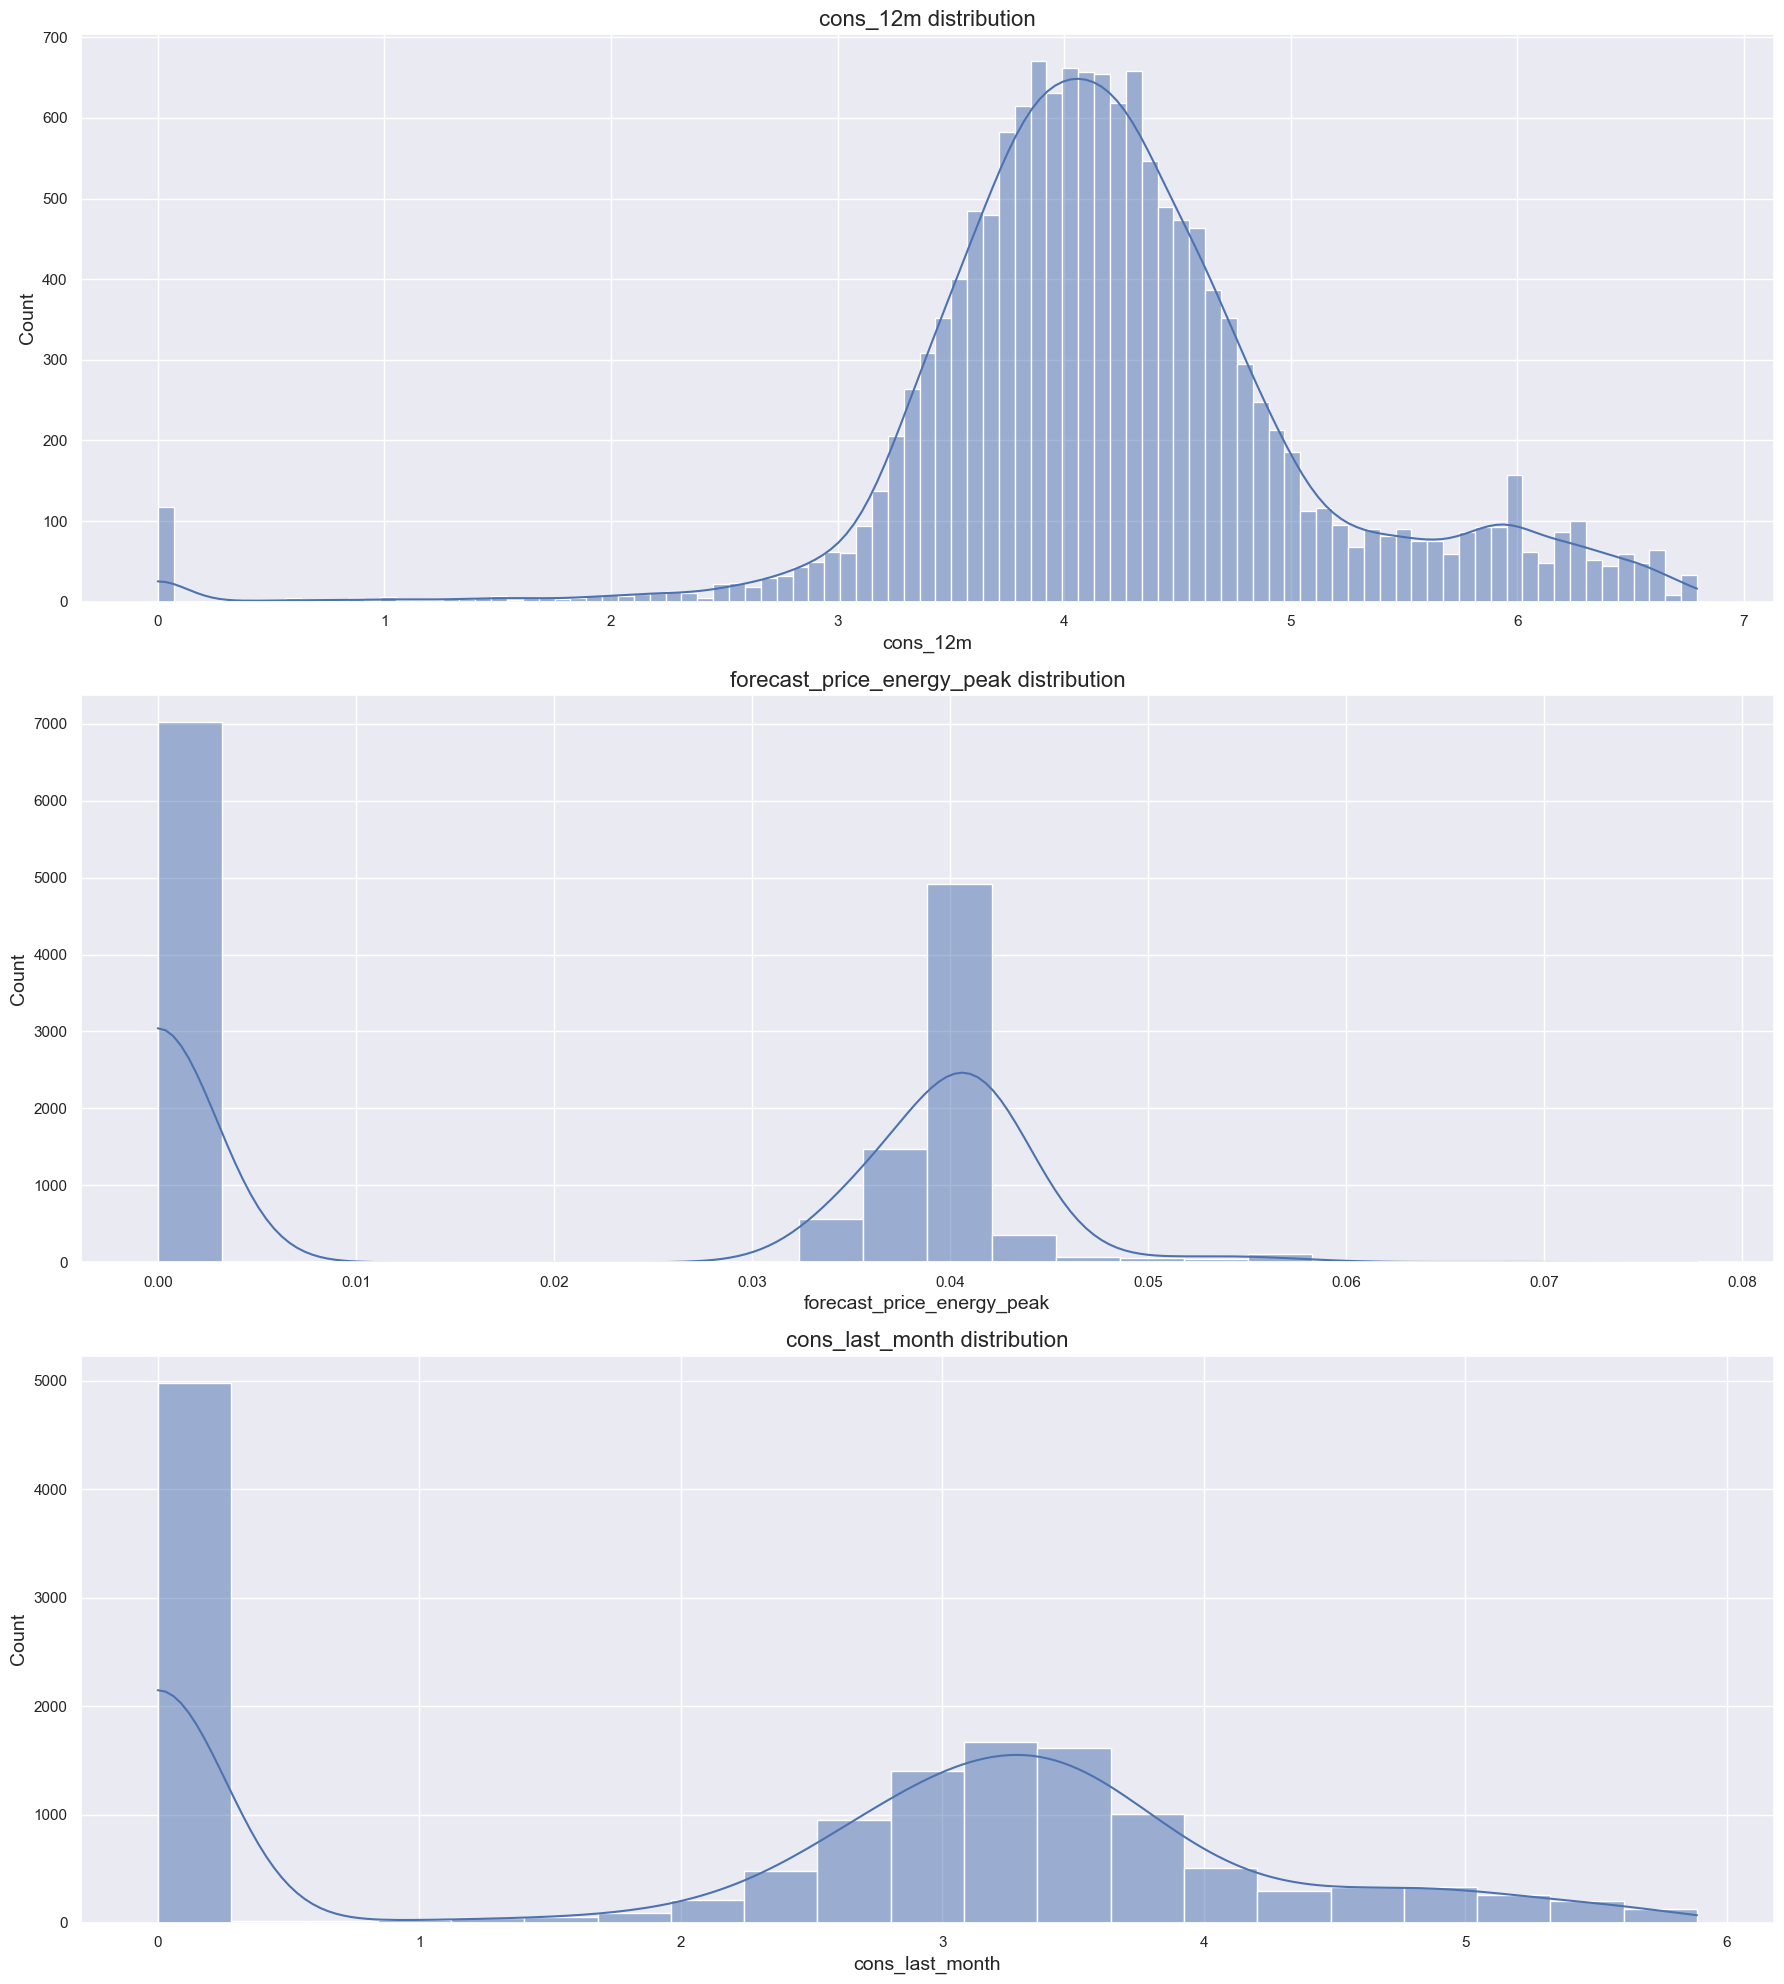

In [23]:
cols = ["cons_12m", "forecast_price_energy_peak", "cons_last_month"]

# Set up subplots
fig, axs = plt.subplots(nrows=len(cols), figsize=(18, 20))

# Loop through each column we chose to plot and plot their histograms
for ax, col in zip(axs, cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"{col} distribution", fontsize=16)
    ax.set_xlabel(col, fontsize=14)
    ax.set_ylabel("Count", fontsize=14)

plt.tight_layout()  # Adjusts subplot parameters (like padding) so that plot elements don't overlap and fit neatly
plt.show()

In [24]:
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_sales_MISSING,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.000000,0.0,0.444045,0.047073,0.040659,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.000000,0.0,1.237292,0.059075,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.000000,0.0,1.599009,0.066622,0.036589,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.000000,0.0,1.318689,0.059448,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,2.721811,0.0,2.122969,0.048014,0.041399,...,71,9,1,0,0,0,0,1,0,0


### Correlations

When you create new features, that requires trial and error and iteration. To determine if we are on the right track, we can check the correlation between our new features and our target variable of interest (in this, churn). We also would want to check if features are highly correlated with each other (and leave only one in the model), since predictive models work best when the features are uncorrelated.

In [25]:
correlation = df.drop(columns=['id']).corr()

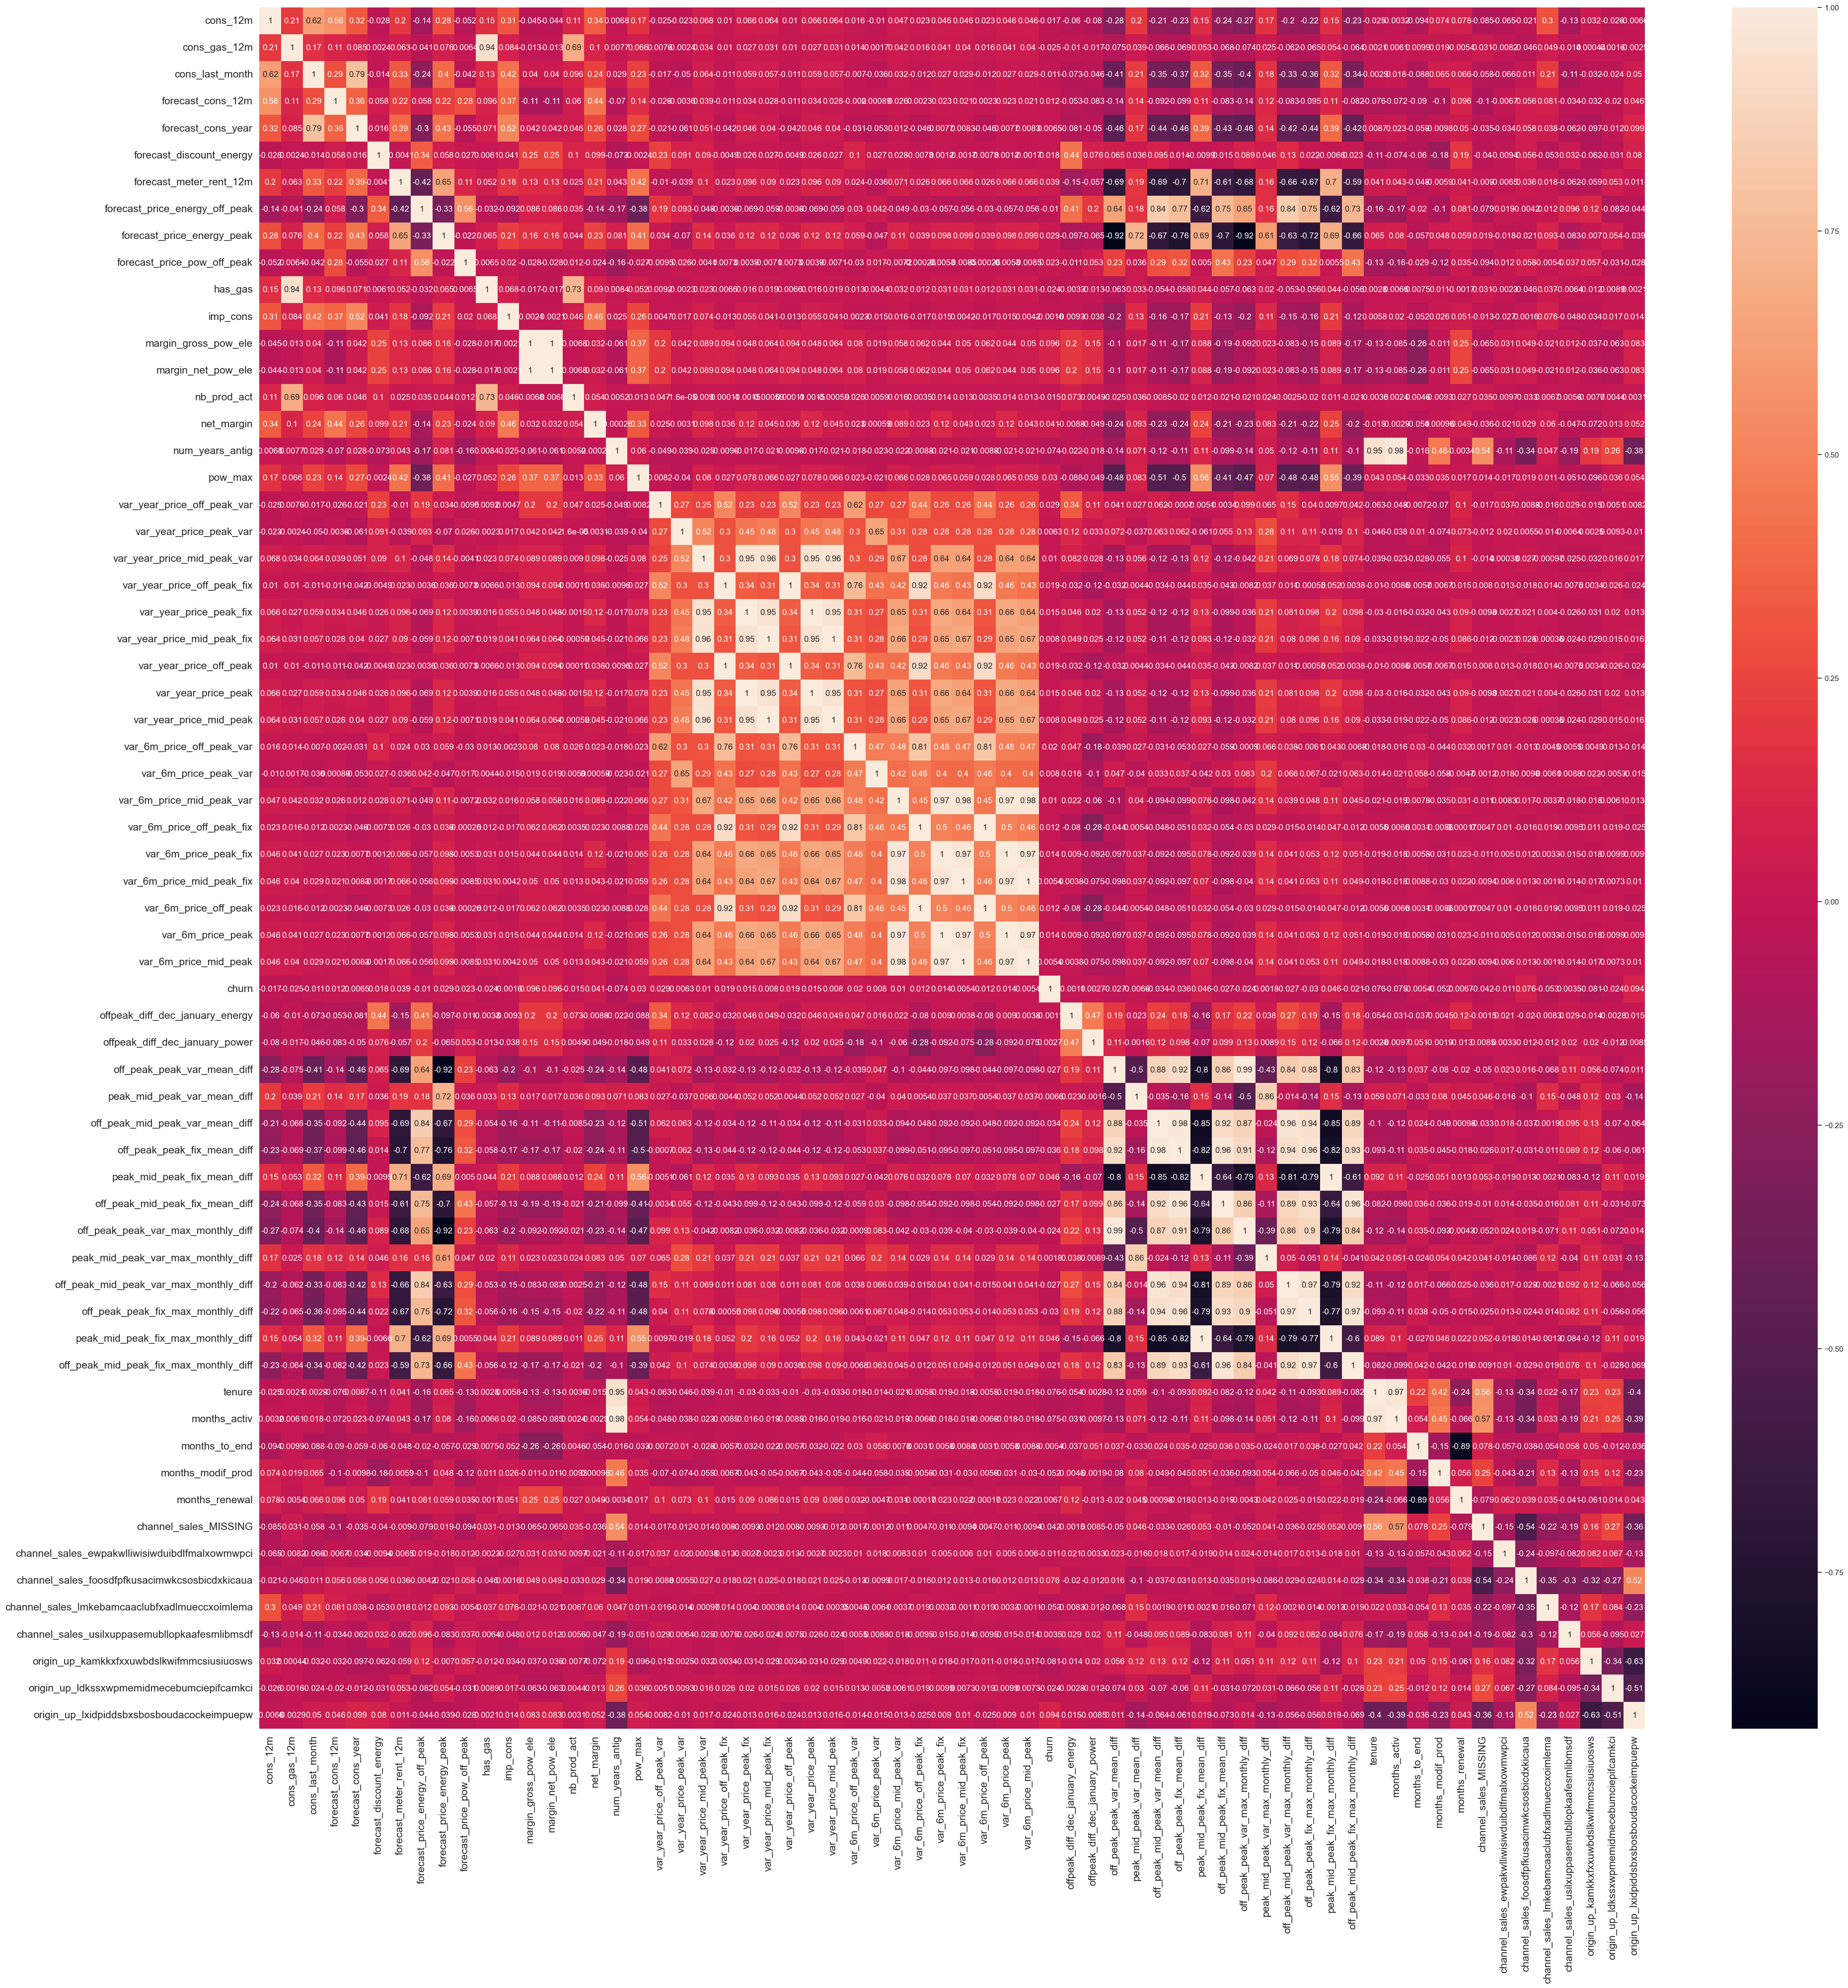

In [26]:
# Plot correlation
plt.figure(figsize=(45, 45))
sns.heatmap(
    correlation, 
    xticklabels=correlation.columns.values,
    yticklabels=correlation.columns.values, 
    annot=True, 
    annot_kws={'size': 12}
)
# Axis ticks size
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()


We will remove two variables that exhibit a high correlation with other independent features.

In [27]:
df = df.drop(columns=['num_years_antig', 'forecast_cons_year'])
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_sales_MISSING,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.047073,0.040659,1.619163,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.059075,0.000000,1.656207,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.066622,0.036589,1.656207,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.059448,0.000000,1.656207,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.048014,0.041399,1.619163,...,71,9,1,0,0,0,0,1,0,0
